313.73737460153257
[[2500, 4300, 65], [2300, 4100, 65], [2100, 4100, 65], [1900, 3900, 65], [1700, 3700, 65], [1766.5640235470275, 3888.5980667165777, 65], [1800.0, 3983.33, 65.0], [1833.128047094055, 4077.1961334331554, 65.0], [1633.128047094055, 4277.196133433155, 65.0], [1715.0187245225372, 4459.6623411273595, 65.0], [1800.0, 4544.64, 79.31249966666665], [1915.0187245225372, 4659.6623411273595, 79.31249966666665], [1989.8760678671379, 4845.124946919979, 79.31249966666665], [2000.0, 4870.21, 79.31249966666665], [2064.7334112117387, 5030.587552712599, 79.31249966666665], [2139.5907545563396, 5216.050158505219, 79.31249966666665], [2200.0, 5365.72, 80.32789966666654], [2214.4480979009404, 5401.512764297839, 80.32789966666654], [2214.4480979009404, 5601.512764297839, 80.32789966666654], [2297.6531693648653, 5783.383366877483, 80.32789966666654], [2380.8582408287903, 5965.253969457128, 80.32789966666654], [2396.75, 6000.0, 80.32789966666654], [2464.063312292715, 6147.124572036772, 80.327

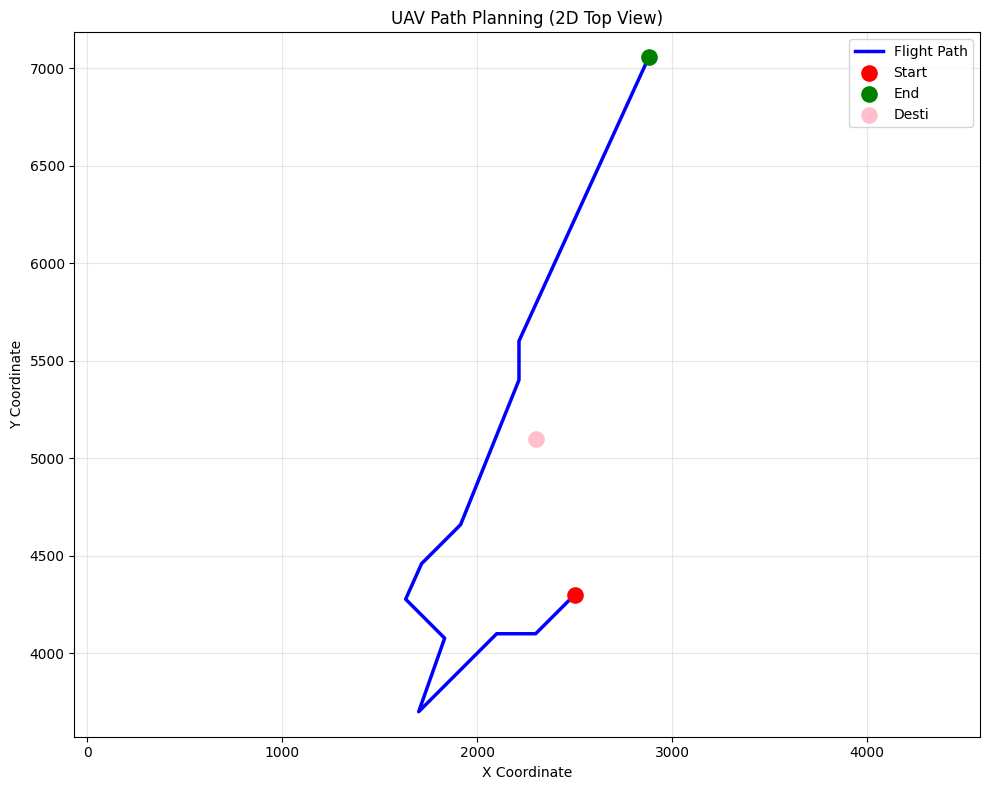

In [16]:
import numpy as np
import heapq
import re
import pandas as pd
import matplotlib.pyplot as plt
import math
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go

SAFE_DISTANCE = 12  #与建筑高度的安全距离
INIT_HEIGHT = 65

df = pd.read_excel("../data/yangpuGrids_.xlsx")
df["maxHeight"] = df["maxHeight"].fillna(0)

def id_xy(gridId):      # grid_Id转成坐标
    n = re.findall(r'\d+', gridId)
    x = int(n[0]) * 200 + 100
    y = int(n[1]) * 200 + 100
    return x, y

def xy_grid(x, y):      # 坐标转成所在格子id
    a = int(x//200)
    b = int(y//200)
    return f"{a}_{b}", a, b

def getHeight(gridId):      # 返回格子最大高度
    a = df.loc[df["gridId"] == gridId, "maxHeight"]
    return a.values[0] if not a.empty else 1111

def move(x, y, x_, y_, curHeight):    #xy->x_y_
    #返回任意点间直线移动时穿过边界时的坐标, 以及时长
    time = 0.0
    xyz = []
    while True:
        dx = x_ - x
        dy = y_ - y
        tan = dy / dx if dx != 0 else float('inf')
        cur_grid_id, cur_grid_x, cur_grid_y = xy_grid(x, y)
        next_grid_x = 0 if dx == 0 else((cur_grid_x + 1) * 200 if dx > 0 else (cur_grid_x - 1) * 200)
        next_grid_y = 0 if dy == 0 else((cur_grid_y + 1) * 200 if dy > 0 else (cur_grid_y - 1) * 200)
        step_x = next_grid_x - x
        step_y = next_grid_y - y
        if(abs(step_x) > abs(dx) or abs(step_y) > abs(dy)):
            break
        if abs(step_x * tan) < abs(step_y):
            step_y = step_x * tan
        elif abs(step_x * tan) > abs(step_y):
            step_x = step_y / tan
        x += step_x
        y += step_y
        x = round(x, 2)
        y = round(y, 2)
        tpid, tpx, tpy = xy_grid(x, y)
        nextHeight = max(getHeight(tpid)+SAFE_DISTANCE, curHeight)
        dHeight = nextHeight - curHeight
        if abs(dHeight / step_x) <= 0.3:
            time += (step_x**2 + step_y**2 + dHeight**2)**0.5/15.5
        else:
            time += max((step_x**2 + step_y**2)/11, dHeight/3)
        curHeight = nextHeight
        curHeight = float(curHeight)
        xyz.append((x, y, curHeight))
    xyz.append((x_, y_, curHeight))
    time += ((x - x_)**2 + (y - y_)**2)**0.5/15.5
    return xyz, time, curHeight

dirs = [    # 若不能直线飞或直线飞开销太大时的备选方向
    (-200, 0),
    (200, 0),
    (0, -200),
    (0, 200),
    (-200, -200),
    (-200, 200),
    (200, -200),
    (200, 200),
]

def eu(x, y, x_, y_):   # 欧距
    dh = abs(getHeight(f"{x}_{y}") - getHeight(f"{x_}_{y_}"))
    return ((x-x_)**2+(y-y_)**2+dh**2)**0.5

def astar(start, end):
    startX, startY = id_xy(start)
    endX, endY = id_xy(end)

    heap = []
    hDrone = max(INIT_HEIGHT, getHeight(start) + SAFE_DISTANCE)
    heapq.heappush(heap, (0.0, startX, startY, hDrone))

    cameFrom = {}
    cost = {}

    cameFrom[(startX, startY, hDrone)] = (-1, -1, -1)
    cost[(startX, startY, hDrone)] = 0.0

    t = 0.0
    traceX, traceY, traceH = 1, 1, 1
    while heap:
        f, x, y, hDrone = heapq.heappop(heap)
        if abs(x - endX) <= 100 and abs(y - endY) <= 100:   # 达到终点
            t = f
            traceX, traceY, traceH = x, y, hDrone
            break
        dirs_ = dirs
        if x != endX and y != endY:
            tan = (y - endY)/(x - endX)
            side = (tan ** 2 + 1)**0.5
            dirs_ = dirs_ + [(200 / side * (-(x - endX)/abs(x - endX)), 200 * tan / side * (-(y - endY)/abs(y - endY)))]
        for dx, dy in dirs_:
            nx = x + dx
            ny = y + dy
            xyz, time, nh = move(x, y, nx, ny, hDrone)
            if nh > 115 or (nh - hDrone) > 25:
                continue
            newC = cost[(x, y, hDrone)] + time
            if(nx, ny, nh) not in cost or newC < cost[(nx, ny, nh)]:
                cameFrom[xyz[0]] = (x, y, hDrone)
                itr = len(xyz) - 1
                while(itr >= 1):
                    cameFrom[xyz[itr]] = xyz[itr - 1]
                    itr -= 1
                cost[(nx, ny, nh)] = newC
                ta, tc, te = move(nx, ny, endX, endY, hDrone)
                nf = newC + tc
                heapq.heappush(heap, (nf, nx, ny, nh))
    path = []
    while (traceX, traceY, traceH) in cameFrom:
        path.append([traceX, traceY, traceH])
        traceX, traceY, traceH = cameFrom[(traceX, traceY, traceH)]
    path.reverse()
    return t, path

t, path = astar("12_21", "14_35")
print(t)
print(path)
def plot_2d_path(path):
    xs = [p[0] for p in path]
    ys = [p[1] for p in path]
    plt.figure(figsize=(10, 8))
    plt.plot(xs, ys, c='blue', linewidth=2.5, label='Flight Path')
    plt.scatter(xs[0], ys[0], c='red', s=120, zorder=5, label='Start')
    plt.scatter(xs[-1], ys[-1], c='green', s=120, zorder=5, label='End')
    endX, endY = id_xy("11_25")
    plt.scatter(endX, endY, c='pink', s=120, zorder=5, label='Desti')
    plt.grid(True, alpha=0.3)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.title('UAV Path Planning (2D Top View)')
    plt.axis('equal')
    plt.legend()
    plt.tight_layout()
    plt.show()
plot_2d_path(path)

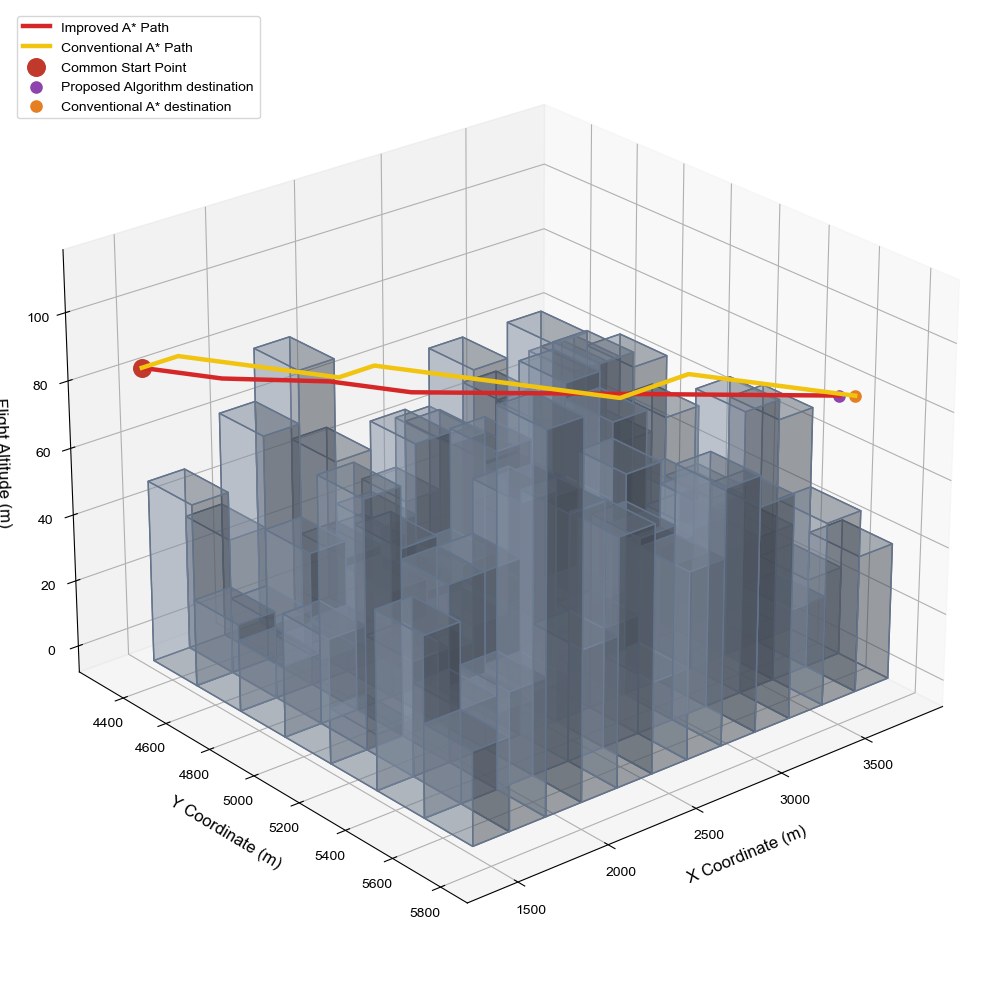

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ================== 1. Load spatial grid dataset ==================
df = pd.read_excel("./display_grids_1.xlsx")

# Convert grid ID (a_b) to grid center X/Y coordinates (meter)
def get_xy(gridId):
    a = int(str(gridId).split("_")[0])
    b = int(str(gridId).split("_")[1])
    x = a * 200 + 100
    y = b * 200 + 100
    return x, y

df[["x", "y"]] = df["gridId"].apply(lambda g: pd.Series(get_xy(g)))
x = df["x"].values
y = df["y"].values
z = df["maxHeight"].fillna(0).values  # Fill empty building height as 0

grid_size = 200  # Grid side length (m)

# ================== 2. Flight trajectory waypoints ==================
# Proposed improved A* trajectory
path = np.array([
    [1500, 4300, np.float64(82.72023299999998)], [1600, 4400, 82.72023299999998],
    [1700, 4500, 82.72023299999998], [1800, 4560.0, 82.72023299999998],
    [1871.4985851425088, 4602.899151085505, 82.72023299999998],
    [2042.9971702850175, 4705.798302171011, 82.72023299999998],
    [2137.2, 4800.0, 82.72023299999998], [2242.9971702850175, 4905.798302171011, 82.72023299999998],
    [2400.0, 4991.38, 82.72023299999998], [2418.6029853994655, 5001.519761092144, 82.72023299999998],
    [2594.2088005139135, 5097.241220013278, 82.72023299999998],
    [2769.8146156283615, 5192.962678934411, 82.72023299999998],
    [2782.72, 5200.0, 82.72023299999998], [2945.4204307428095, 5288.684137855545, 82.72023299999998],
    [3121.0262458572574, 5384.405596776678, 82.72023299999998],
    [3149.63, 5400.0, 82.72023299999998], [3296.6320609717054, 5480.127055697812, 82.72023299999998],
    [3472.2378760861534, 5575.848514618946, 82.72023299999998],
    [3516.54, 5600.0, 82.72023299999998], [3647.8436912006014, 5671.569973540079, 82.72023299999998]
])
path_x = path[:, 0]
path_y = path[:, 1]
path_z = path[:, 2]

# Conventional grid A* trajectory
path_baseline = np.array([
    [1500, 4300, 82.72023299999998], [1700, 4300, 82.72023299999998],
    [1900, 4500, 82.72023299999998], [2100, 4700, 82.72023299999998],
    [2300, 4700, 82.72023299999998], [2500, 4900, 82.72023299999998],
    [2700, 5100, 82.72023299999998], [2900, 5300, 82.72023299999998],
    [3100, 5300, 82.72023299999998], [3300, 5300, 82.72023299999998],
    [3500, 5500, 82.72023299999998], [3700, 5700, 82.72023299999998]
])
path_x_base = path_baseline[:, 0]
path_y_base = path_baseline[:, 1]
path_z_base = path_baseline[:, 2]

# ================== 3. Initialize 3D Figure ==================
# Disable Chinese font config (all labels converted to English)
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Draw building blocks (muted neutral color, low transparency to avoid covering trajectories)
for xi, yi, zi in zip(x, y, z):
    if zi > 0:
        ax.bar3d(
            xi - grid_size//2,
            yi - grid_size//2,
            0,
            grid_size, grid_size, zi,
            color="#94a3b8",
            edgecolor="#64748b",
            alpha=0.3
        )

# Plot flight trajectories (journal-standard high-distinction colors)
# Proposed Improved A*: Deep red
ax.plot(
    path_x, path_y, path_z,
    color='#d62728',
    linewidth=3.2,
    label='Improved A* Path',
    zorder=100
)
# Conventional A*: Golden yellow
ax.plot(
    path_x_base, path_y_base, path_z_base,
    color='#f1c40f',
    linewidth=3.2,
    label='Conventional A* Path',
    zorder=100
)

# Mark start & terminal points
ax.scatter(path_x[0], path_y[0], path_z[0], color='#c0392b', s=160, zorder=101, label='Common Start Point')
ax.scatter(path_x[-1], path_y[-1], path_z[-1], color='#8e44ad', s=65, zorder=101, label='Proposed Algorithm destination')
ax.scatter(path_x_base[-1], path_y_base[-1], path_z_base[-1], color='#e67e22', s=65, zorder=101, label='Conventional A* destination')

# ================== 4. Axis & Layout Configuration (All English) ==================
ax.set_xlabel('X Coordinate (m)', fontsize=12, labelpad=8)
ax.set_ylabel('Y Coordinate (m)', fontsize=12, labelpad=8)
ax.set_zlabel('Flight Altitude (m)', fontsize=12, labelpad=8)

# View angle adjustment
ax.view_init(elev=25, azim=50)
ax.invert_xaxis()

# Legend & layout
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('3D_flight_trajectory_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

164.092125125461
[[1500, 4500, np.float64(66.26743299999993)], [1700, 4500, np.float64(66.26743299999993)], [1800, 4560.0, 79.31249966666665], [1871.4985851425088, 4602.899151085505, 79.31249966666665], [2042.9971702850175, 4705.798302171011, 79.31249966666665], [2200.0, 4800.0, 79.31249966666665], [2214.4957554275265, 4808.6974532565155, 79.31249966666665], [2385.9943405700355, 4911.596604342021, 79.31249966666665], [2400.0, 4925.6, 79.31249966666665], [2585.9943405700355, 5111.596604342021, 79.31249966666665], [2600.0, 5118.99, 79.31249966666665], [2762.84140247224, 5205.004937463632, 79.31249966666665], [2939.6884643744447, 5298.413270585243, 79.31249966666665], [3116.5355262766493, 5391.821603706853, 79.31249966666665], [3132.02, 5400.0, 79.31249966666665], [3293.382588178854, 5485.229936828464, 79.31249966666665], [3470.229650081058, 5578.6382699500755, 79.31249966666665], [3510.67, 5600.0, 79.31249966666665], [3647.0767119832626, 5672.046603071686, 79.31249966666665]]


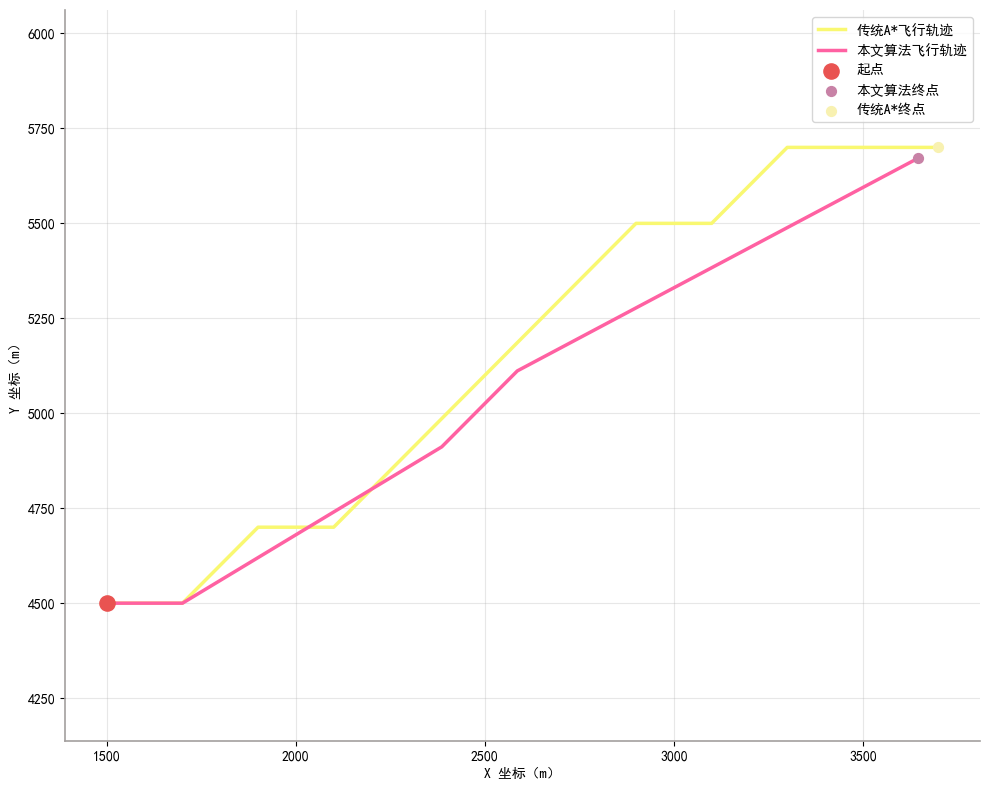

In [57]:
import numpy as np
import heapq
import re
import pandas as pd
import matplotlib.pyplot as plt
import math
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go

SAFE_DISTANCE = 12  #与建筑高度的安全距离
INIT_HEIGHT = 65

df = pd.read_excel("../data/yangpuGrids_.xlsx")
df["maxHeight"] = df["maxHeight"].fillna(0)

def id_xy(gridId):      # grid_Id转成坐标
    n = re.findall(r'\d+', gridId)
    x = int(n[0]) * 200 + 100
    y = int(n[1]) * 200 + 100
    return x, y

def xy_grid(x, y):      # 坐标转成所在格子id
    a = int(x//200)
    b = int(y//200)
    return f"{a}_{b}", a, b

def getHeight(gridId):      # 返回格子最大高度
    a = df.loc[df["gridId"] == gridId, "maxHeight"]
    return a.values[0] if not a.empty else 1111

def move(x, y, x_, y_, curHeight):    #xy->x_y_
    #返回任意点间直线移动时穿过边界时的坐标, 以及时长
    time = 0.0
    xyz = []
    while True:
        dx = x_ - x
        dy = y_ - y
        tan = dy / dx if dx != 0 else float('inf')
        cur_grid_id, cur_grid_x, cur_grid_y = xy_grid(x, y)
        next_grid_x = 0 if dx == 0 else((cur_grid_x + 1) * 200 if dx > 0 else (cur_grid_x - 1) * 200)
        next_grid_y = 0 if dy == 0 else((cur_grid_y + 1) * 200 if dy > 0 else (cur_grid_y - 1) * 200)
        step_x = next_grid_x - x
        step_y = next_grid_y - y
        if(abs(step_x) > abs(dx) or abs(step_y) > abs(dy)):
            break
        if abs(step_x * tan) < abs(step_y):
            step_y = step_x * tan
        elif abs(step_x * tan) > abs(step_y):
            step_x = step_y / tan
        x += step_x
        y += step_y
        x = round(x, 2)
        y = round(y, 2)
        tpid, tpx, tpy = xy_grid(x, y)
        nextHeight = max(getHeight(tpid)+SAFE_DISTANCE, curHeight)
        dHeight = nextHeight - curHeight
        if abs(dHeight / step_x) <= 0.3:
            time += (step_x**2 + step_y**2 + dHeight**2)**0.5/15.5
        else:
            time += max((step_x**2 + step_y**2)/11, dHeight/3)
        curHeight = nextHeight
        curHeight = float(curHeight)
        xyz.append((x, y, curHeight))
    xyz.append((x_, y_, curHeight))
    time += ((x - x_)**2 + (y - y_)**2)**0.5/15.5
    return xyz, time, curHeight

dirs = [    # 若不能直线飞或直线飞开销太大时的备选方向
    (-200, 0),
    (200, 0),
    (0, -200),
    (0, 200),
    (-200, -200),
    (-200, 200),
    (200, -200),
    (200, 200),
]

def eu(x, y, x_, y_):   # 欧距
    dh = abs(getHeight(f"{x}_{y}") - getHeight(f"{x_}_{y_}"))
    return ((x-x_)**2+(y-y_)**2+dh**2)**0.5

def astar(start, end):
    startX, startY = id_xy(start)
    endX, endY = id_xy(end)

    heap = []
    hDrone = max(INIT_HEIGHT, getHeight(start) + SAFE_DISTANCE)
    heapq.heappush(heap, (0.0, startX, startY, hDrone))

    cameFrom = {}
    cost = {}

    cameFrom[(startX, startY, hDrone)] = (-1, -1, -1)
    cost[(startX, startY, hDrone)] = 0.0

    t = 0.0
    traceX, traceY, traceH = 1, 1, 1
    while heap:
        f, x, y, hDrone = heapq.heappop(heap)
        if abs(x - endX) <= 100 and abs(y - endY) <= 100:   # 达到终点
            t = f
            traceX, traceY, traceH = x, y, hDrone
            break
        dirs_ = dirs
        if x != endX and y != endY:
            side = ((x - endX)**2 + (y - endY)**2)**0.5
            dirs_ = dirs_ + [(200 / side * (endX - x), 200 / side * (endY - y))]
        for dx, dy in dirs_:
            nx = x + dx
            ny = y + dy
            xyz, time, nh = move(x, y, nx, ny, hDrone)
            if nh > 115 or (nh - hDrone) > 25:
                continue
            newC = cost[(x, y, hDrone)] + time
            if(nx, ny, nh) not in cost or newC < cost[(nx, ny, nh)]:
                cameFrom[xyz[0]] = (x, y, hDrone)
                itr = len(xyz) - 1
                while(itr >= 1):
                    cameFrom[xyz[itr]] = xyz[itr - 1]
                    itr -= 1
                cost[(nx, ny, nh)] = newC
                ta, tc, te = move(nx, ny, endX, endY, hDrone)
                nf = newC + tc
                heapq.heappush(heap, (nf, nx, ny, nh))
    path = []
    while (traceX, traceY, traceH) in cameFrom:
        path.append([traceX, traceY, traceH])
        traceX, traceY, traceH = cameFrom[(traceX, traceY, traceH)]
    path.reverse()
    return t, path

t, path = astar("7_22", "18_28")
print(t)
print(path)
path_ = [[1500, 4500, 66.26743299999993], [1700, 4500, 66.26743299999993], [1900, 4700, 66.26743299999993], [2100, 4700, 66.26743299999993], [2300, 4900, 66.26743299999993], [2500, 5100, 66.26743299999993], [2700, 5300, 66.26743299999993], [2900, 5500, 66.26743299999993], [3100, 5500, 66.26743299999993], [3300, 5700, 66.26743299999993], [3500, 5700, 66.26743299999993], [3700, 5700, 66.26743299999993]]
def plot_2d_path(path, path_):
    xs = [p[0] for p in path]
    ys = [p[1] for p in path]
    xs_ = [p[0] for p in path_]
    ys_ = [p[1] for p in path_]
    plt.figure(figsize=(10, 8))
    plt.plot(xs_, ys_, c="#f9f871", linewidth=2.5, label='传统A*飞行轨迹')
    plt.plot(xs, ys, c='#ff61a2', linewidth=2.5, label='本文算法飞行轨迹')
    plt.scatter(xs[0], ys[0], c='#E95351', s=120, zorder=5, label='起点')
    plt.scatter(xs[-1], ys[-1], c="#C882A6", s=50, zorder=5, label='本文算法终点')
    plt.scatter(xs_[-1], ys_[-1], c="#F8F1B1", s=50, zorder=5, label='传统A*终点')
    plt.grid(True, alpha=0.3)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#a39f9e')
    ax.spines['bottom'].set_color('#a39f9e')
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    plt.xlabel('X 坐标（m）')
    plt.ylabel('Y 坐标（m）')
    plt.axis('equal')
    plt.legend()
    plt.tight_layout()
    # plt.savefig("route.png")
plot_2d_path(path, path_)

Proposed Algorithm Total Flight Time: 164.09 s
Proposed Algorithm Flight Waypoints:
[[1500, 4500, 66.26743299999993], [1700, 4500, 66.26743299999993], [1800, 4560.0, 79.31249966666665], [1871.4985851425088, 4602.899151085505, 79.31249966666665], [2042.9971702850175, 4705.798302171011, 79.31249966666665], [2200.0, 4800.0, 79.31249966666665], [2214.4957554275265, 4808.6974532565155, 79.31249966666665], [2385.9943405700355, 4911.596604342021, 79.31249966666665], [2400.0, 4925.6, 79.31249966666665], [2585.9943405700355, 5111.596604342021, 79.31249966666665], [2600.0, 5118.99, 79.31249966666665], [2762.84140247224, 5205.004937463632, 79.31249966666665], [2939.6884643744447, 5298.413270585243, 79.31249966666665], [3116.5355262766493, 5391.821603706853, 79.31249966666665], [3132.02, 5400.0, 79.31249966666665], [3293.382588178854, 5485.229936828464, 79.31249966666665], [3470.2296500810585, 5578.6382699500755, 79.31249966666665], [3510.67, 5600.0, 79.31249966666665], [3647.076711983263, 5672.04

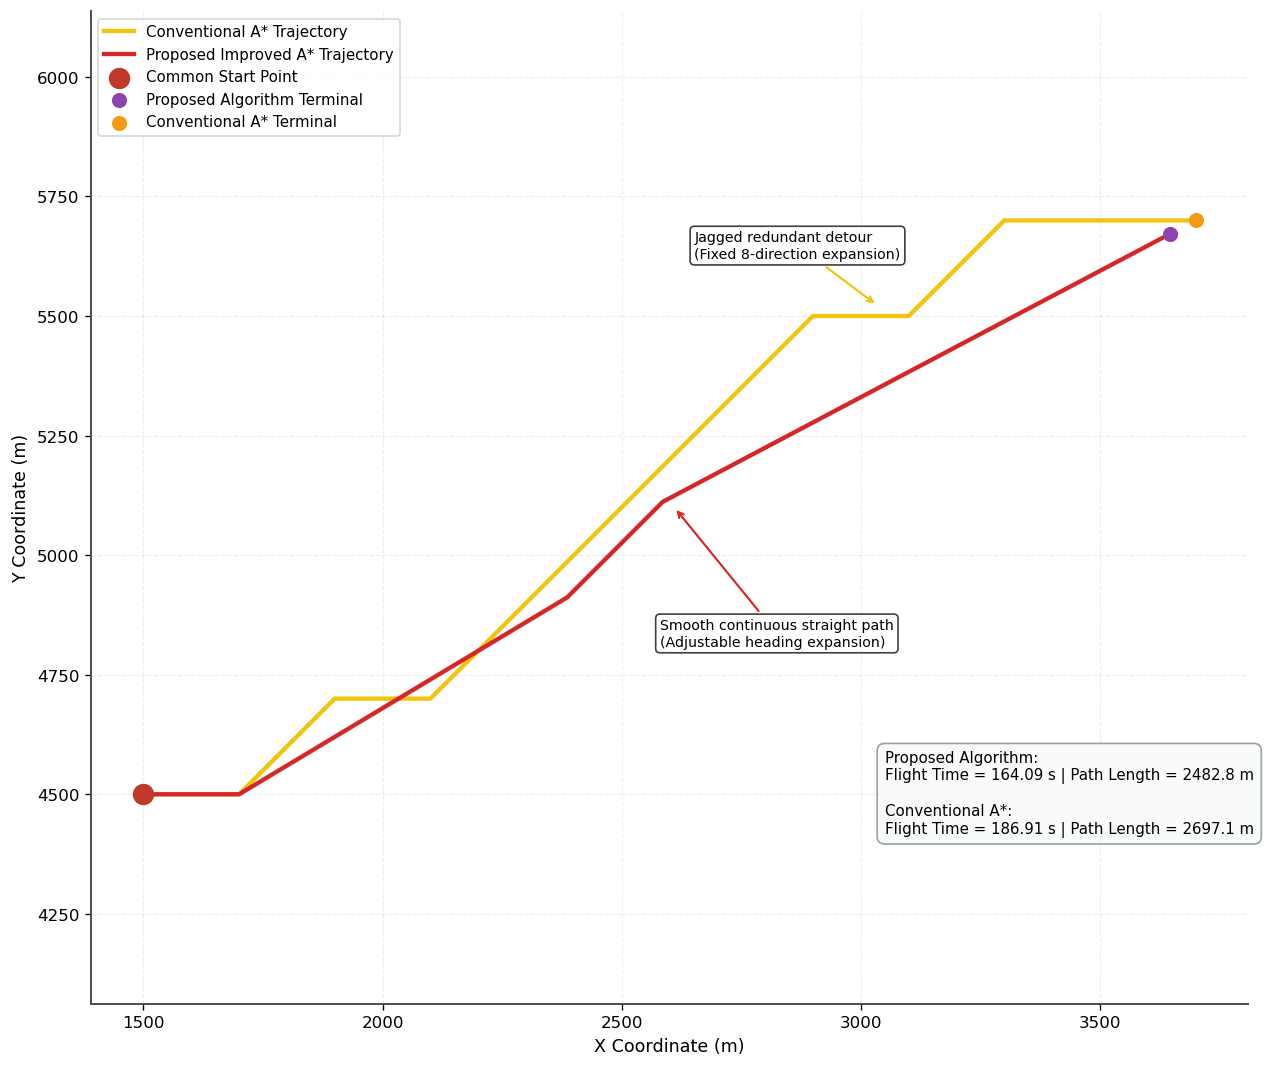

In [2]:
import numpy as np
import heapq
import re
import pandas as pd
import matplotlib.pyplot as plt
import math
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go

# Global flight constraints (Unit: meter, m/s)
SAFE_DISTANCE = 12        # Vertical safety clearance above buildings
INIT_HEIGHT = 65          # Minimum legal flight altitude

# Load Yangpu District grid dataset
df = pd.read_excel("../data/yangpuGridsHeight.xlsx")
df["maxHeight"] = df["maxHeight"].fillna(0)

def id_xy(gridId):
    """Convert grid ID (a_b) to center X/Y coordinates (m)"""
    num_list = re.findall(r'\d+', gridId)
    x = int(num_list[0]) * 200 + 100
    y = int(num_list[1]) * 200 + 100
    return x, y

def xy_grid(x, y):
    """Convert X/Y coordinate to corresponding grid ID, grid index a, b"""
    grid_a = int(x // 200)
    grid_b = int(y // 200)
    return f"{grid_a}_{grid_b}", grid_a, grid_b

def getHeight(gridId):
    """Return maximum building height inside target grid cell"""
    height_series = df.loc[df["gridId"] == gridId, "maxHeight"]
    return height_series.values[0] if not height_series.empty else 1111

def move(x, y, target_x, target_y, curHeight):
    """
    Traverse straight line between two points across grid boundaries
    Return: waypoint sequence, total segment flight time, final flight altitude
    """
    seg_time = 0.0
    waypoint_xyz = []
    while True:
        dx_total = target_x - x
        dy_total = target_y - y
        tan_slope = dy_total / dx_total if dx_total != 0 else float('inf')
        cur_grid_id, cur_gx, cur_gy = xy_grid(x, y)

        # Calculate adjacent grid boundary coordinate
        if dx_total == 0:
            next_gx = 0
        else:
            next_gx = (cur_gx + 1) * 200 if dx_total > 0 else (cur_gx - 1) * 200
        if dy_total == 0:
            next_gy = 0
        else:
            next_gy = (cur_gy + 1) * 200 if dy_total > 0 else (cur_gy - 1) * 200

        step_x = next_gx - x
        step_y = next_gy - y
        if abs(step_x) > abs(dx_total) or abs(step_y) > abs(dy_total):
            break

        # Adjust step to fit straight line trajectory
        if abs(step_x * tan_slope) < abs(step_y):
            step_y = step_x * tan_slope
        elif abs(step_x * tan_slope) > abs(step_y):
            step_x = step_y / tan_slope

        x += step_x
        y += step_y
        x = round(x, 2)
        y = round(y, 2)
        tp_id, tp_gx, tp_gy = xy_grid(x, y)

        # Update required flight altitude for obstacle avoidance
        req_next_h = max(getHeight(tp_id) + SAFE_DISTANCE, curHeight)
        delta_h = req_next_h - curHeight

        # Time calculation under kinematic constraints
        horizontal_dist = math.hypot(step_x, step_y)
        climb_slope = abs(delta_h / horizontal_dist) if horizontal_dist != 0 else 999
        three_d_dist = math.sqrt(step_x**2 + step_y**2 + delta_h**2)
        if climb_slope <= 0.3:
            seg_time += three_d_dist / 15.5
        else:
            seg_time += max(horizontal_dist / 11, delta_h / 3)

        curHeight = float(req_next_h)
        waypoint_xyz.append((x, y, curHeight))

    # Final small segment to target coordinate
    final_h_dist = math.hypot(x - target_x, y - target_y)
    seg_time += final_h_dist / 15.5
    waypoint_xyz.append((target_x, target_y, curHeight))
    return waypoint_xyz, seg_time, curHeight

# 8 fixed adjacent directions for conventional A* expansion
fixed_dirs = [
    (-200, 0),
    (200, 0),
    (0, -200),
    (0, 200),
    (-200, -200),
    (-200, 200),
    (200, -200),
    (200, 200),
]

def euclidean_dist(x, y, target_x, target_y):
    """3D Euclidean distance heuristic for baseline A*"""
    h1 = getHeight(f"{int(x//200)}_{int(y//200)}")
    h2 = getHeight(f"{int(target_x//200)}_{int(target_y//200)}")
    dh = abs(h1 - h2)
    return math.sqrt((x-target_x)**2 + (y-target_y)**2 + dh**2)

def improved_astar(start_grid_id, end_grid_id):
    """Proposed improved A* with continuous heading expansion & physics cost function"""
    startX, startY = id_xy(start_grid_id)
    endX, endY = id_xy(end_grid_id)

    priority_heap = []
    init_flight_h = max(INIT_HEIGHT, getHeight(start_grid_id) + SAFE_DISTANCE)
    heapq.heappush(priority_heap, (0.0, startX, startY, init_flight_h))

    backtrack_map = {}
    cost_record = {}
    backtrack_map[(startX, startY, init_flight_h)] = (-1, -1, -1)
    cost_record[(startX, startY, init_flight_h)] = 0.0

    total_flight_time = 0.0
    final_x, final_y, final_h = 1, 1, 1

    while priority_heap:
        f_cost, x, y, cur_h = heapq.heappop(priority_heap)
        # Termination threshold: within 100m of target grid center
        if abs(x - endX) <= 100 and abs(y - endY) <= 100:
            total_flight_time = f_cost
            final_x, final_y, final_h = x, y, cur_h
            break

        candidate_dirs = fixed_dirs.copy()
        # Add straight-line heading toward destination as extra search direction
        if not (x == endX and y == endY):
            planar_dist = math.hypot(x - endX, y - endY)
            direct_dx = 200 / planar_dist * (endX - x)
            direct_dy = 200 / planar_dist * (endY - y)
            candidate_dirs.append((direct_dx, direct_dy))

        for dx_step, dy_step in candidate_dirs:
            nx = x + dx_step
            ny = y + dy_step
            seg_waypoints, seg_t, new_h = move(x, y, nx, ny, cur_h)
            # Prune paths violating altitude regulatory constraints
            if new_h > 115 or (new_h - cur_h) > 25:
                continue

            accumulated_cost = cost_record[(x, y, cur_h)] + seg_t
            state_key = (nx, ny, new_h)
            if state_key not in cost_record or accumulated_cost < cost_record[state_key]:
                # Record full waypoint backtrack links
                backtrack_map[seg_waypoints[0]] = (x, y, cur_h)
                idx = len(seg_waypoints) - 1
                while idx >= 1:
                    backtrack_map[seg_waypoints[idx]] = seg_waypoints[idx - 1]
                    idx -= 1
                cost_record[state_key] = accumulated_cost
                # Estimate heuristic h(n) for priority queue sorting
                _, h_time, _ = move(nx, ny, endX, endY, new_h)
                full_f = accumulated_cost + h_time
                heapq.heappush(priority_heap, (full_f, nx, ny, new_h))

    # Reconstruct full flight path by backtracking
    full_path = []
    current_state = (final_x, final_y, final_h)
    while current_state in backtrack_map:
        full_path.append([current_state[0], current_state[1], current_state[2]])
        current_state = backtrack_map[current_state]
    full_path.reverse()
    return total_flight_time, full_path

# Run improved A* test
total_time_proposed, path_proposed = improved_astar("7_22", "18_28")
print(f"Proposed Algorithm Total Flight Time: {total_time_proposed:.2f} s")
print("Proposed Algorithm Flight Waypoints:")
print(path_proposed)

# Baseline conventional A* flight path (your precomputed result)
path_baseline = [
    [1500, 4500, 66.26743299999993], [1700, 4500, 66.26743299999993],
    [1900, 4700, 66.26743299999993], [2100, 4700, 66.26743299999993],
    [2300, 4900, 66.26743299999993], [2500, 5100, 66.26743299999993],
    [2700, 5300, 66.26743299999993], [2900, 5500, 66.26743299999993],
    [3100, 5500, 66.26743299999993], [3300, 5700, 66.26743299999993],
    [3500, 5700, 66.26743299999993], [3700, 5700, 66.26743299999993]
]

def plot_2d_trajectory_comparison(path_proposed, path_baseline, t_proposed, t_baseline, len_proposed, len_baseline):
    """
    Generate 2D top-down trajectory comparison figure for journal paper
    :param path_proposed: waypoint list of improved A*
    :param path_baseline: waypoint list of conventional grid A*
    :param t_proposed: total flight time of proposed algorithm (s)
    :param t_baseline: total flight time of baseline algorithm (s)
    :param len_proposed: total planar distance of proposed path (m)
    :param len_baseline: total planar distance of baseline path (m)
    """
    # Extract coordinate sequences
    x_p = [p[0] for p in path_proposed]
    y_p = [p[1] for p in path_proposed]
    x_b = [p[0] for p in path_baseline]
    y_b = [p[1] for p in path_baseline]

    plt.figure(figsize=(11, 9), dpi=120)

    # Plot two trajectories with journal-friendly colors
    # Yellow: Conventional A*, Pink-Red: Proposed Improved A*
    plt.plot(x_b, y_b, color="#f1c40f", linewidth=2.6, label="Conventional A* Trajectory")
    plt.plot(x_p, y_p, color="#d62728", linewidth=2.6, label="Proposed Improved A* Trajectory")

    # Mark start & end points
    plt.scatter(x_p[0], y_p[0], c="#c0392b", s=140, zorder=10, label="Common Start Point")
    plt.scatter(x_p[-1], y_p[-1], c="#8e44ad", s=65, zorder=9, label="Proposed Algorithm Terminal")
    plt.scatter(x_b[-1], y_b[-1], c="#f39c12", s=65, zorder=9, label="Conventional A* Terminal")

    # Add core text annotations to raise information density
    # Annotate jagged detour segment of baseline algorithm
    # plt.text(2050, 4680, "Jagged redundant detour\n(Fixed 8-direction expansion)",
    #          fontsize=8.5, bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.75))
    # # Annotate smooth straight trajectory of proposed algorithm
    # plt.text(2600, 5200, "Smooth continuous straight path\n(Adjustable heading expansion)",
    #          fontsize=8.5, bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.75))
    # Quantitative comparison text box at top-right blank area
    plt.annotate(
    "Jagged redundant detour\n(Fixed 8-direction expansion)",
    xy=(3035, 5522),          # 箭头指向黄色折线拐点
    xytext=(2652, 5622),      # 文字框位置（左上远离红线）
    fontsize=8.5,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.75),
    arrowprops=dict(arrowstyle="->", color="#f1c40f", lw=1.3)
    )

# 2. 红色改进算法平滑直线路径标注，红色箭头指向红色斜线
    plt.annotate(
        "Smooth continuous straight path\n(Adjustable heading expansion)",
        xy=(2610, 5100),          # 箭头指向红色平滑路径
        xytext=(2580, 4811),      # 文字框位置（右上远离黄线）
        fontsize=8.5,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.75),
        arrowprops=dict(arrowstyle="->", color="#d62728", lw=1.3)
    )
    info_text = (
        f"Proposed Algorithm:\n"
        f"Flight Time = {t_proposed:.2f} s | Path Length = {len_proposed:.1f} m\n\n"
        f"Conventional A*:\n"
        f"Flight Time = {t_baseline:.2f} s | Path Length = {len_baseline:.1f} m"
    )
    plt.text(3050, 4420, info_text, fontsize=9,
             bbox=dict(boxstyle="round,pad=0.5", fc="#f8f9fa", ec="#7f8c8d", alpha=0.8))

    # Grid setting: match 200m grid division of Yangpu District
    plt.grid(True, alpha=0.22, linestyle="--", linewidth=0.7)
    ax = plt.gca()

    # Clean axis spines for academic style
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#505050')
    ax.spines['bottom'].set_color('#505050')
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)

    # Axis labels (English, unit meter)
    plt.xlabel("X Coordinate (m)", fontsize=10.5)
    plt.ylabel("Y Coordinate (m)", fontsize=10.5)
    plt.axis('equal')
    plt.legend(loc="upper left", fontsize=9)
    plt.tight_layout()
    plt.savefig("trajectory_2d_comparison.png", bbox_inches="tight")
    plt.show()
def calc_path_length(waypoint_list):
    """
    计算整条轨迹的平面XY总长度、三维XYZ总长度
    :param waypoint_list: 路径点列表 [[x,y,h], [x,y,h], ...]
    :return: planar_len(平面总长m), space_len(三维总长m)
    """
    planar_len = 0.0
    space_len = 0.0
    for i in range(len(waypoint_list)-1):
        x1, y1, h1 = waypoint_list[i]
        x2, y2, h2 = waypoint_list[i+1]
        dx = x2 - x1
        dy = y2 - y1
        dh = h2 - h1
        planar_len += math.hypot(dx, dy)
        space_len += math.sqrt(dx**2 + dy**2 + dh**2)
    return round(planar_len, 2), round(space_len, 2)
# ---------------------- Usage Instructions ----------------------
# You need to fill these 4 variables with your conventional A* test data:
time_baseline = 186.906856441788    # Total flight time of traditional A* (fill your real value)
# len_proposed = calc_path_length(path_proposed)     # Total planar length of improved path
# len_baseline = calc_path_length(path_baseline)    # Total planar length of traditional path
len_proposed, space_p = calc_path_length(path_proposed)
len_baseline, space_b = calc_path_length(path_baseline)
# Call plotting function
plot_2d_trajectory_comparison(
    path_proposed=path_proposed,
    path_baseline=path_baseline,
    t_proposed=total_time_proposed,
    t_baseline=time_baseline,
    len_proposed=len_proposed,
    len_baseline=len_baseline
) 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# ====================== 读入两个表 ======================
df_diff = pd.read_excel("差值.xlsx", index_col=0)
df_orig = pd.read_excel("compare_matrix.xlsx", index_col=0)

def parse_id(s):
    nums = re.findall(r'\d+', str(s))
    return int(nums[0]), int(nums[1])

index_ids = df_diff.index.tolist()
col_ids = df_diff.columns.tolist()

dist_list = []
ratio_list = []

# 遍历计算距离 + 耗时降低百分比
for i, start_id in enumerate(index_ids):
    x1, y1 = parse_id(start_id)
    for j, end_id in enumerate(col_ids):
        diff = df_diff.iloc[i, j]
        orig = df_orig.iloc[i, j]

        if pd.isna(diff) or pd.isna(orig) or diff == 0 or orig <= 0:
            continue
        if diff > 0:
            continue

        x2, y2 = parse_id(end_id)
        dx = x2 - x1
        dy = y2 - y1
        dist = np.sqrt(dx**2 + dy**2) * 200

        # 降低百分比转正
        reduce_ratio = -(diff / orig) * 100

        dist_list.append(dist)
        ratio_list.append(reduce_ratio)

df_data = pd.DataFrame({
    "distance": dist_list,
    "reduce_pct": ratio_list
})

# ========== ✅ 去掉等于 0 的数据 ==========
df_data = df_data[df_data["reduce_pct"] != 0]

# ========== 过滤极端值 ==========
df_data = df_data[(df_data["reduce_pct"] >= 0) & (df_data["reduce_pct"] <= 60)]

# ========== 距离分段 ==========
bins = [0, 200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000, 3000]
labels = ["0-200","200-400","400-600",
          "600-800","800-1000","1000-1200","1200-1400","1400-1600",
          "1600-1800","1800-2000",">2000"]
df_data["dist_bin"] = pd.cut(df_data["distance"], bins=bins, labels=labels)

# ========== 计算每组中位数（用于画折线） ==========
medians = df_data.groupby("dist_bin")["reduce_pct"].median()
x_pos = np.arange(1, len(labels)+1)

# ========== 绘图：箱线图 + 折线 ==========
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(12, 6))

# 画箱线
groups = [df_data[df_data["dist_bin"]==lab]["reduce_pct"].values for lab in labels]
bp = plt.boxplot(groups, patch_artist=True, showfliers=False)

# 箱体颜色
for box in bp["boxes"]:
    box.set_facecolor("#5959FF")
    box.set_alpha(0.7)

# ====================== ✅ 在这里加折线（中位数） ======================
plt.plot(x_pos, medians.values, color="#FF4D4F", linewidth=3, marker='o', markersize=7, label="中位数趋势")

# 坐标轴
plt.xticks(x_pos, labels, rotation=30)
plt.xlabel("距离区间")
plt.ylabel("耗时降低百分比(%)")
# plt.title("不同距离区间耗时降低百分比分布")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from openpyxl import load_workbook

# Read data into DataFrame
df = pd.read_excel("../data/yangpuGridsHeight.xlsx""../data/yangpuGridsHeight.xlsx")
print(f"Data loaded, total rows: {len(df)}")
print("Column names:", df.columns.tolist())

# Split gridId into horizontal coordinate x and vertical coordinate y
def split_xy(gid):
    x, y = str(gid).split("_")
    return int(x), int(y)

df[["x", "y"]] = df["gridId"].apply(lambda s: pd.Series(split_xy(s)))

# Calculate grid dimension
max_x = df["x"].max()
max_y = df["y"].max()
cols = max_x + 1
rows = max_y + 1
print(f"Grid size: {cols} columns (horizontal) × {rows} rows (vertical)")

# Construct elevation matrix
height_mat = np.zeros((rows, cols))
for _, row in df.iterrows():
    height_mat[row["y"], row["x"]] = row["maxHeight"]

# Plot configuration
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(16, 11), dpi=120)

# Color map: YlOrRd (light yellow → orange → deep red, same as reference graph)
im = ax.imshow(height_mat, cmap="YlOrRd", aspect=1)

# Color bar
cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label("Grid Height (m)", fontsize=11)

# Axis ticks: show label every 10 grids
x_ticks = np.arange(0, cols, 10)
y_ticks = np.arange(0, rows, 10)
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)

# Axis labels & title
ax.set_xlabel("Index x", fontsize=12)
ax.set_ylabel("Index y", fontsize=12)

# Hide black grid lines
ax.grid(False)

plt.tight_layout()

# Export high-resolution figure
output_png = "grid_height_YlOrRd.png"
plt.savefig(output_png, dpi=300, bbox_inches="tight")
print(f"Visualization figure saved to: {output_png}")

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# File path config
INPUT_EXCEL = "../data/yangpuGridsHeight_with_pop.xlsx"

# Read grid data with population
df = pd.read_excel(INPUT_EXCEL)
print(f"Data loaded, total grid rows: {len(df)}")
print("Column names:", df.columns.tolist())

# Split gridId into horizontal x and vertical y index
def split_xy(gid):
    x, y = str(gid).split("_")
    return int(x), int(y)

df[["x", "y"]] = df["gridId"].apply(lambda s: pd.Series(split_xy(s)))

# Calculate grid matrix size
max_x = df["x"].max()
max_y = df["y"].max()
col_count = max_x + 1
row_count = max_y + 1
print(f"Grid dimension: {col_count} columns × {row_count} rows")

# Build population matrix
pop_matrix = np.zeros((row_count, col_count))
for _, row in df.iterrows():
    pop_matrix[row["y"], row["x"]] = row["population"]

# Plot style setup
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(16, 11), dpi=120)

# Same yellow-orange-red color map as your population reference figure
im = ax.imshow(pop_matrix, cmap="YlOrRd", aspect=1)

# Color bar setting
cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label("Total Population per Grid Cell", fontsize=11)

# Ticks: only show label every 10 cells
x_ticks = np.arange(0, col_count, 10)
y_ticks = np.arange(0, row_count, 10)
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)

# Axis labels and title (all English)
ax.set_xlabel("Index x", fontsize=12)
ax.set_ylabel("Index y", fontsize=12)

# Hide black dividing grid lines
ax.grid(False)

plt.tight_layout()

# Save high resolution figure
output_img = "grid_population_heatmap.png"
plt.savefig(output_img, dpi=300, bbox_inches="tight")
print(f"Population heatmap saved to: {output_img}")

plt.show()